<a href="https://colab.research.google.com/github/trishitsingla/cricket-analytics/blob/main/notebooks/02_bowler_pressure_and_control_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

import sys
sys.path.append('/content/drive/MyDrive/cricket-analytics/src')

import utils

In [2]:
df = pd.read_csv("/content/drive/MyDrive/cricket-analytics/data/processed/deliveries.csv")

df.head()

/tmp/ipykernel_14683/3151378979.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/cricket-analytics/data/processed/deliveries.csv")


,match_id,match_type,city,event,start_date,end_date,gender,inning,batting_team,over,...,runs_batter,runs_extras,runs_total,wides,noballs,byes,legbyes,penalty,is_ball_faced,wicket
0,438938,MDM,Nairobi,ICC Intercontinental Shield,2010-02-20,2010-02-23,male,1,Netherlands,0,...,1,0,1,0,0,0,0,0,1,0
1,438938,MDM,Nairobi,ICC Intercontinental Shield,2010-02-20,2010-02-23,male,1,Netherlands,0,...,0,1,1,0,0,0,1,0,1,0
2,438938,MDM,Nairobi,ICC Intercontinental Shield,2010-02-20,2010-02-23,male,1,Netherlands,0,...,0,0,0,0,0,0,0,0,1,0
3,438938,MDM,Nairobi,ICC Intercontinental Shield,2010-02-20,2010-02-23,male,1,Netherlands,0,...,4,0,4,0,0,0,0,0,1,0
4,438938,MDM,Nairobi,ICC Intercontinental Shield,2010-02-20,2010-02-23,male,1,Netherlands,0,...,0,0,0,0,0,0,0,0,1,0


In [3]:
df.columns

Index(['match_id', 'match_type', 'city', 'event', 'start_date', 'end_date',
       'gender', 'inning', 'batting_team', 'over', 'ball', 'batter', 'bowler',
       'runs_batter', 'runs_extras', 'runs_total', 'wides', 'noballs', 'byes',
       'legbyes', 'penalty', 'is_ball_faced', 'wicket'],
      dtype='object')

In [4]:
# Core flags
df["is_dot"] = (df["runs_total"] == 0).astype(int)
df["is_boundary"] = (df["runs_total"] >= 4).astype(int)
df["is_wicket"] = (df["wicket"] == 1).astype(int)
df["legal_ball"] = ((df["wides"]==0) & (df["noballs"]==0)).astype(int)
df["is_dot_bowler"] = ((df["runs_batter"] == 0) & (df['legal_ball'] == 1)).astype(int)

In [5]:
df = utils.add_match_phase(df)

In [6]:
df_legal = df[df["legal_ball"] == 1]

In [7]:
def top_bowlers(df: pd.DataFrame, phase: str, format: str, threshold_balls: int = 500) -> pd.DataFrame:
  if phase == 'all':
    filtered_df = df[(df["match_type"] == format)]
  else:
    filtered_df = df[(df["phase"] == phase) & (df["match_type"] == format)]

  bowler_stats = (
    filtered_df.groupby("bowler")
    .agg(
        runs_conceded=("runs_total", "sum"),
        balls=("legal_ball", "sum"),
        dot_balls=("is_dot", "sum"),
        boundaries=("is_boundary", "sum"),
        wickets=("is_wicket", "sum")
    )
    .reset_index()
)
  bowler_stats["overs"] = (
    (bowler_stats["balls"] // 6).astype(int).astype(str)
    + "."
    + (bowler_stats["balls"] % 6).astype(int).astype(str)
)
  bowler_stats["economy"] = bowler_stats["runs_conceded"] / (bowler_stats["balls"]/6)

  bowler_stats["dot_pct"] = bowler_stats["dot_balls"] / bowler_stats["balls"]
  bowler_stats["boundary_pct"] = bowler_stats["boundaries"] / bowler_stats["balls"]
  bowler_stats["wickets_per_ball"] = bowler_stats["wickets"] / bowler_stats["balls"]
  phase_stats = (
    filtered_df.groupby(["bowler", "phase"])
    .agg(
        runs=("runs_total", "sum"),
        balls=("legal_ball", "sum")
    )
    .reset_index()
)

  phase_stats["economy"] = phase_stats["runs"] / (phase_stats["balls"] / 6)
  phase_pivot = phase_stats.pivot(
    index="bowler",
    columns="phase",
    values="economy"
).reset_index()

  bowler_stats = bowler_stats.merge(phase_pivot, on="bowler", how="left")

  scaler = MinMaxScaler()

  bowler_stats["econ_norm"] = scaler.fit_transform(
      bowler_stats[["economy"]]
  )

  bowler_stats["boundary_norm"] = scaler.fit_transform(
      bowler_stats[["boundary_pct"]]
  )

  bowler_stats["pressure_score"] = (
    0.35 * bowler_stats["dot_pct"]
    - 0.25 * bowler_stats["boundary_norm"]
    - 0.20 * bowler_stats["econ_norm"]
    + 0.20 * bowler_stats["wickets_per_ball"]
  )
  bowler_stats = bowler_stats[bowler_stats["balls"] > threshold_balls]

  top_bowlers_list = bowler_stats.sort_values(
    "pressure_score", ascending=False
  ).head(20)

  plt.figure(figsize=(8,6))
  plt.barh(top_bowlers_list["bowler"], top_bowlers_list["pressure_score"])
  plt.title("Top Bowlers by Pressure Score")
  plt.xlabel("Pressure Score")
  plt.gca().invert_yaxis()
  plt.show()

  return top_bowlers_list

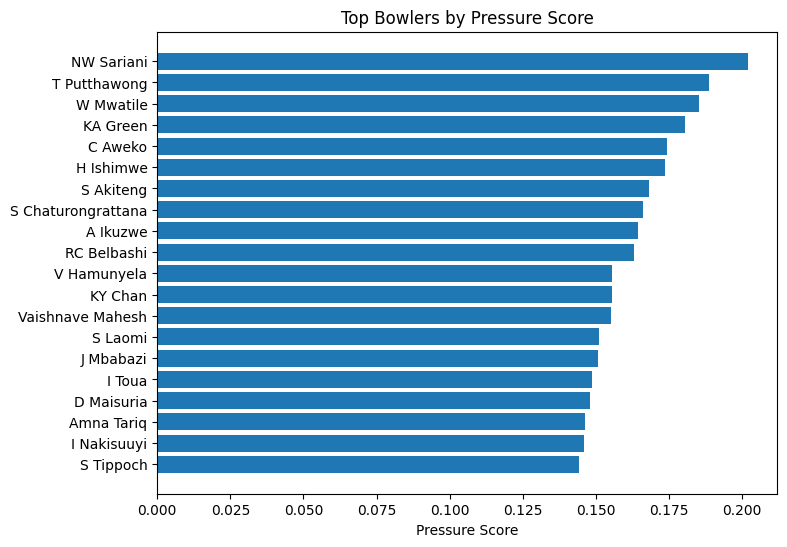

,bowler,runs_conceded,balls,dot_balls,boundaries,wickets,overs,economy,dot_pct,boundary_pct,wickets_per_ball,middle,econ_norm,boundary_norm,pressure_score
4386,NW Sariani,271,503,314,19,40,83.5,3.232604,0.624254,0.037773,0.079523,3.232604,0.115450,0.037773,0.201860
6203,T Putthawong,365,587,363,35,40,97.5,3.730835,0.618399,0.059625,0.068143,3.730835,0.133244,0.059625,0.188513
6607,W Mwatile,366,594,372,39,26,99.0,3.696970,0.626263,0.065657,0.043771,3.696970,0.132035,0.065657,0.185125
3029,KA Green,452,726,429,33,42,121.0,3.735537,0.590909,0.045455,0.057851,3.735537,0.133412,0.045455,0.180342
1094,C Aweko,404,611,356,35,40,101.5,3.967267,0.582651,0.057283,0.065466,3.967267,0.141688,0.057283,0.174363
2146,H Ishimwe,560,831,485,56,62,138.3,4.043321,0.583634,0.067389,0.074609,4.043321,0.144404,0.067389,0.173466
5257,S Akiteng,580,890,500,42,50,148.2,3.910112,0.561798,0.047191,0.056180,3.910112,0.139647,0.047191,0.168138
5285,S Chaturongrattana,458,657,376,47,44,109.3,4.182648,0.572298,0.071537,0.066971,4.182648,0.149380,0.071537,0.165938
87,A Ikuzwe,429,603,342,42,41,100.3,4.268657,0.567164,0.069652,0.067993,4.268657,0.152452,0.069652,0.164203
4967,RC Belbashi,495,758,424,37,28,126.2,3.918206,0.559367,0.048813,0.036939,3.918206,0.139936,0.048813,0.162976


In [8]:
top_bowlers(df_legal, 'middle', 'T20')